# Ploteando con xarray

La librería xarray tiene una función ``plot`` integrada, que es un wrapper alrededor de la librería matplotlib.

Como los arreglos de datos de xarray contienen todos los metadatos asociados y coordenadas para los datos, eso puede crear plots informativos con poco esfuerzo.

El primer paso es importar xarray

In [1]:
import xarray

Siguiente paso es usar una función de jupyter que permite que las figuras matplotlib sean mostradas dentro del notebook

In [2]:
%matplotlib inline

/home/peter/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Ahora abrimos el mismo dataset como antes

In [3]:
ds = xarray.open_dataset('jro20250516_132000.nc')

Es el ``xarray.DataArray`` que tiene un método ``plot`` definido, eso no funciona en un ``xarray.Dataset``. Así para plotear, el primer perfil temporal de ``ne`` es:

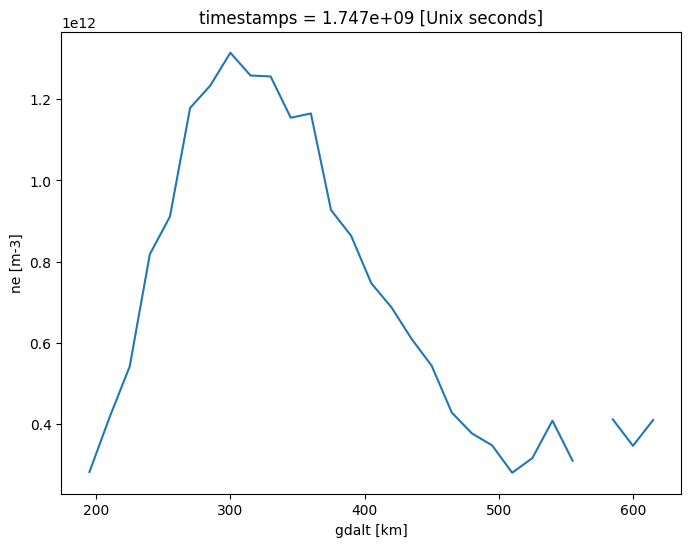

In [9]:
ne = ds.ne
ne.isel(timestamps=0).plot(size=6)

El operador encadenando significa que es posible tener multiple selección de operadores y añadir ``.plot`` al final para visualizar el resultado

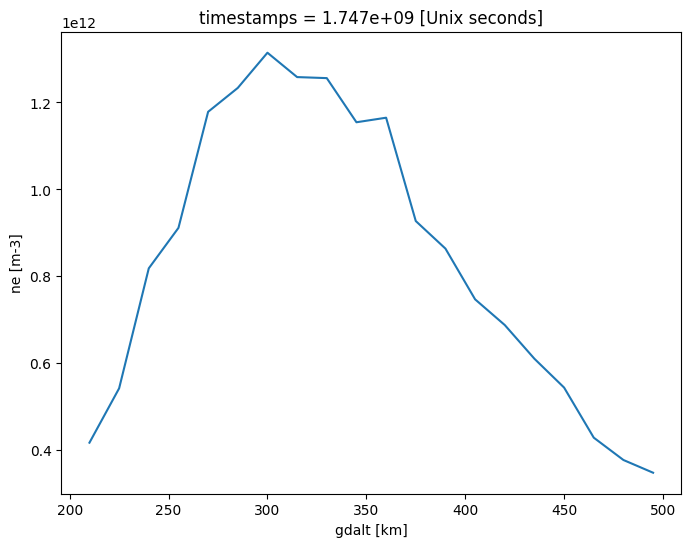

In [10]:
ne.isel(timestamps=0).sel(gdalt=slice(200, 500)).plot(size=6)

xarray automaticamente adivinará el tipo de plot basado en la dimensionalidad de los datos siendo ploteados. Si ocurre muchas dimensiones ``xarray`` por defecto mostrará un histograma. Pero también puedes definir las componentes de tu ploteo y xarray los ploteará según lo definido

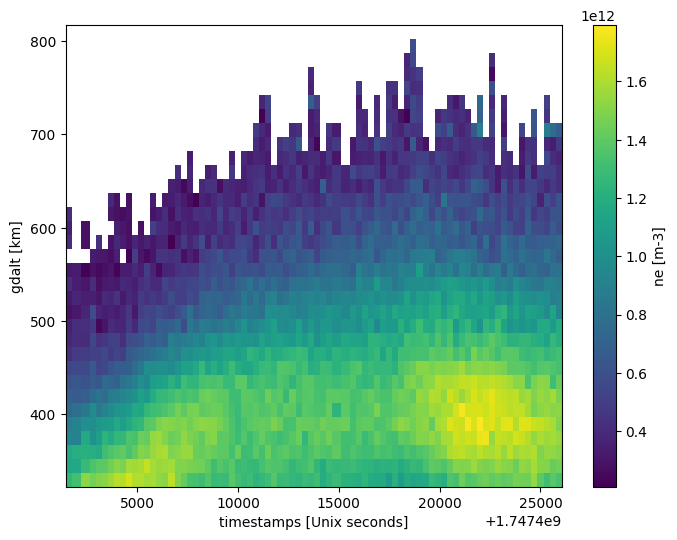

In [16]:
# Corta los primeros 80 perfiles de tiempo y la zona entre 300km y 600km de altura
# NOTA: Agregamos x y y explícitos para que xarray dibuje el mapa a color sin errores
ne.isel(timestamps=slice(0, 80), gdalt=slice(10, 50)).plot(x='timestamps', y='gdalt', size=6)

Si reducimos lo suficiente la dimensionalidad entonces podremos obtener un plot más simple. Como observamos en el gráfico, una serie temporal de densidad de electrones a nua altura de 405 km (Es necesario seleccionar datos específicos al usar ``sel``, o usar el argumento ``method`` para como elegir el dato a plotear)

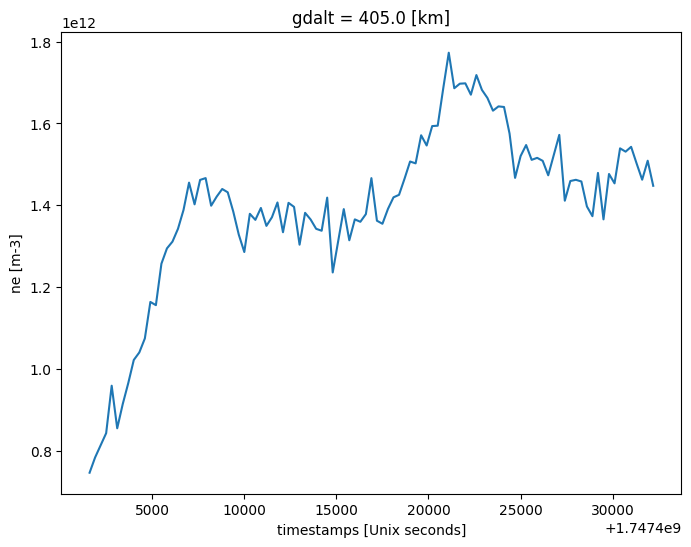

In [12]:
# Evolución de la densidad a lo largo de los primeros 100 tiempos a una altura fija de 400 km
ne.isel(timestamps=slice(0, 100)).sel(gdalt=400, method='nearest').plot(size=6)

Además, apartando los datos una parte de datos temporales en función de su índice y para un rango de alturas, y ploteando un perfil de la densidad de electrones de la ionósfera. Además se puede usar ``yincrease=False`` para invertir el eje y, pero esto es usualemente usado para otro tipo de datos de decresen conforme se incrementa una observación espefícica (Por ejemplo, el brillo de luz de una estrella es más brillante mientras menor es su magnitud)

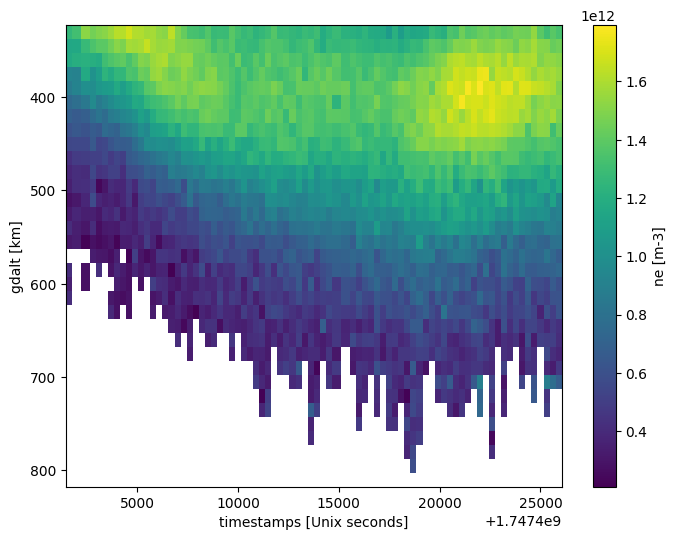

In [18]:
ne.isel(timestamps=slice(0, 80), gdalt=slice(10, 50)).plot(x='timestamps', y='gdalt', size=6, yincrease=False)